# AIAP Past Year Practise Case Study 

In [8]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("../data/score.db")

# sqlite_master is SQLite's built-in catalog: a hidden table that lists everything in the database (tables, indexes, etc.)
tables = pd.read_sql("SELECT name FROm sqlite_master WHERE type = 'table'", conn)
print(tables)

# Ttkes the first table's name and loads the entire table into a DataFrame
df = pd.read_sql(f"SELECT * FROM {tables.iloc[0,0]}", conn)
conn.close()

print(df.shape)
df.info()
print(df.isna().sum())
print(df.describe(include="all"))
df.head(5)

    name
0  score
(15900, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  object 
 3   CCA                 15900 non-null  object 
 4   learning_style      15900 non-null  object 
 5   student_id          15900 non-null  object 
 6   gender              15900 non-null  object 
 7   tuition             15900 non-null  object 
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  object 
 15  wake_time           159

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


## Data preprocessing

In [18]:
print(df['CCA'].unique())

print(df['learning_style'].unique())

print(df['tuition'].unique())

print(df['gender'].unique())
print(df['student_id'].duplicated().sum())  # how many repeats
print(df.drop(columns=['index', 'bag_color']).duplicated().sum())
df[df['student_id'].duplicated(keep=False)].sort_values('student_id')   # show every row involved
cols = df.columns.drop(['index', 'bag_color'])
dup_rows = df[df['student_id'].duplicated(keep=False)]

# for each duplicated ID, count how many distinct values each column has
diff = dup_rows.groupby('student_id')[cols].nunique(dropna=False)

# keep only IDs where some column has more than 1 distinct value
conflicts = diff[(diff > 1).any(axis=1)]
print(len(conflicts))
print((conflicts > 1).sum())   # which columns cause the conflicts

print(df['age'].value_counts().sort_index())

['Sports' 'None' 'Clubs' 'Arts' 'ARTS' 'SPORTS' 'CLUBS' 'NONE']
['Visual' 'Auditory']
['No' 'Yes' 'Y' 'N']
['Female' 'Male']
900
765
135
number_of_siblings     0
direct_admission       0
CCA                    0
learning_style         0
student_id             0
gender                 0
tuition                0
final_test            52
n_male                 0
n_female               0
age                    0
hours_per_week         0
attendance_rate       90
sleep_time             0
wake_time              0
mode_of_transport      0
dtype: int64
age
-5.0        4
-4.0        1
 5.0      216
 6.0      230
 15.0    7726
 16.0    7723
Name: count, dtype: int64


In [53]:
def data_processing(df):
    df = df.copy()

    # 1. Deduplicate: keep the most complete record per student
    df['n_missing'] = df.isna().sum(axis=1)
    df = (df.sort_values('n_missing')
            .drop_duplicates(subset='student_id', keep='first')
            .drop(columns='n_missing'))

    # 2. Standardise inconsistent categories
    df['CCA'] = df['CCA'].str.capitalize()         

    # 3. Remove impossible ages and replace age 5:15 6:16
    df = df[df['age'] > 0]                             
    df['age'] = df['age'].replace({5:15, 6:16})

    # 4. Drop rows with no target (can't train or evaluate on them)
    df = df.dropna(subset=['final_test'])

    # 5. Rename Y, N in tuition to match 'Yes', 'No'
    df['tuition'] = df['tuition'].replace({'Y':'Yes', 'N':'No'})

    # 6. total hours slept from sleep_time and wake_time columns
    sleep = pd.to_datetime(df['sleep_time'], format='%H:%M')
    wake  = pd.to_datetime(df['wake_time'],  format='%H:%M')
    sleep_h = sleep.dt.hour + sleep.dt.minute / 60    # "22:30" -> 22.5
    wake_h  = wake.dt.hour  + wake.dt.minute / 60     # "6:30"  -> 6.5
    df['sleep_hours'] = (wake_h - sleep_h) % 24

    # 7. Total classmates instead of just n_male, n_female
    df['n_classmates'] = df['n_male'] + df['n_female']
    
    return df.reset_index(drop=True)

In [54]:
df_cleaned = data_processing(df)
print(df_cleaned.columns)

Index(['index', 'number_of_siblings', 'direct_admission', 'CCA',
       'learning_style', 'student_id', 'gender', 'tuition', 'final_test',
       'n_male', 'n_female', 'age', 'hours_per_week', 'attendance_rate',
       'sleep_time', 'wake_time', 'mode_of_transport', 'bag_color',
       'sleep_hours', 'n_classmates'],
      dtype='object')


## EDA visualisations

## Distribution of final_test

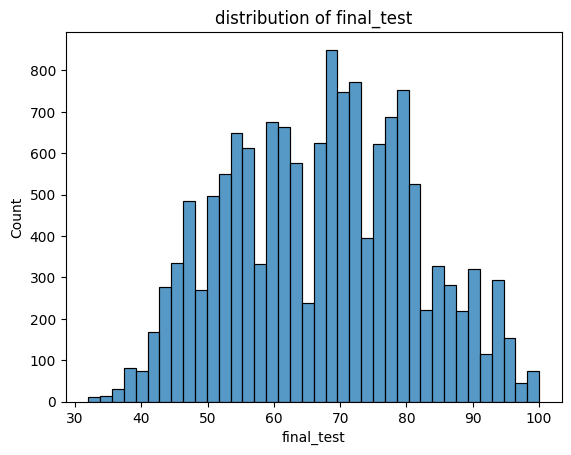

In [55]:
sns.histplot(x='final_test', data= df_cleaned)
plt.title('distribution of final_test')
plt.show()

## Qualitative Variables against final_test

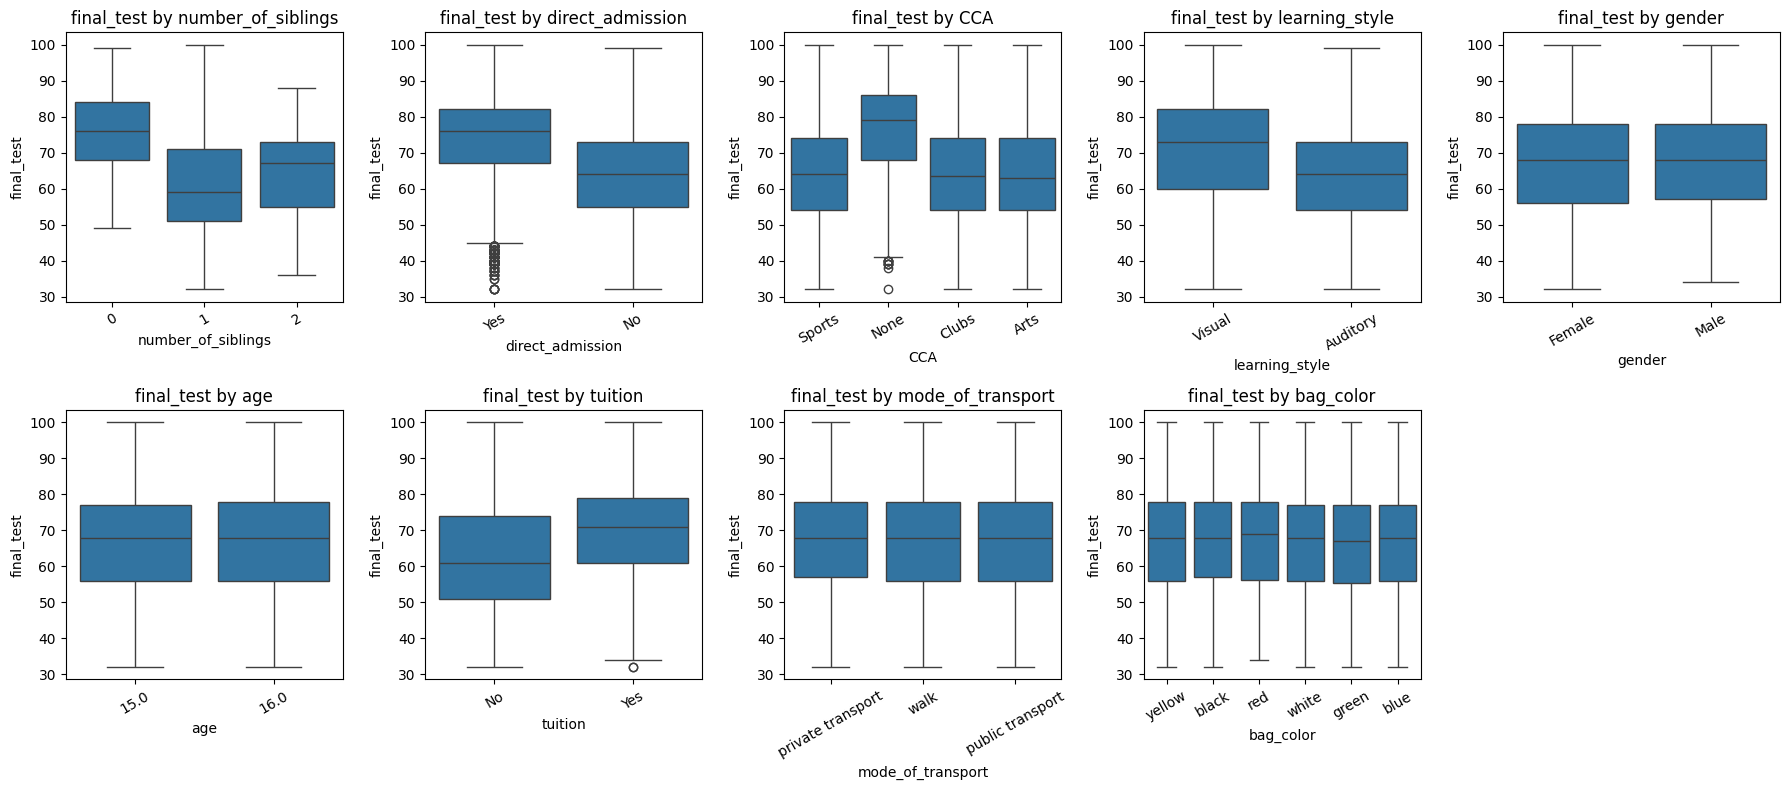

In [56]:
cat_cols = ['number_of_siblings', 'direct_admission', 'CCA', 'learning_style', 
            'gender','age', 'tuition', 'mode_of_transport', 'bag_color']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))   # 2 rows x 5 columns of plots
axes = axes.flatten()                              # turn the grid into a flat list

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df_cleaned, x=col, y='final_test', ax=ax)
    ax.set_title(f'final_test by {col}')
    ax.tick_params(axis='x', rotation=30)
    
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Quantitative vs final_score

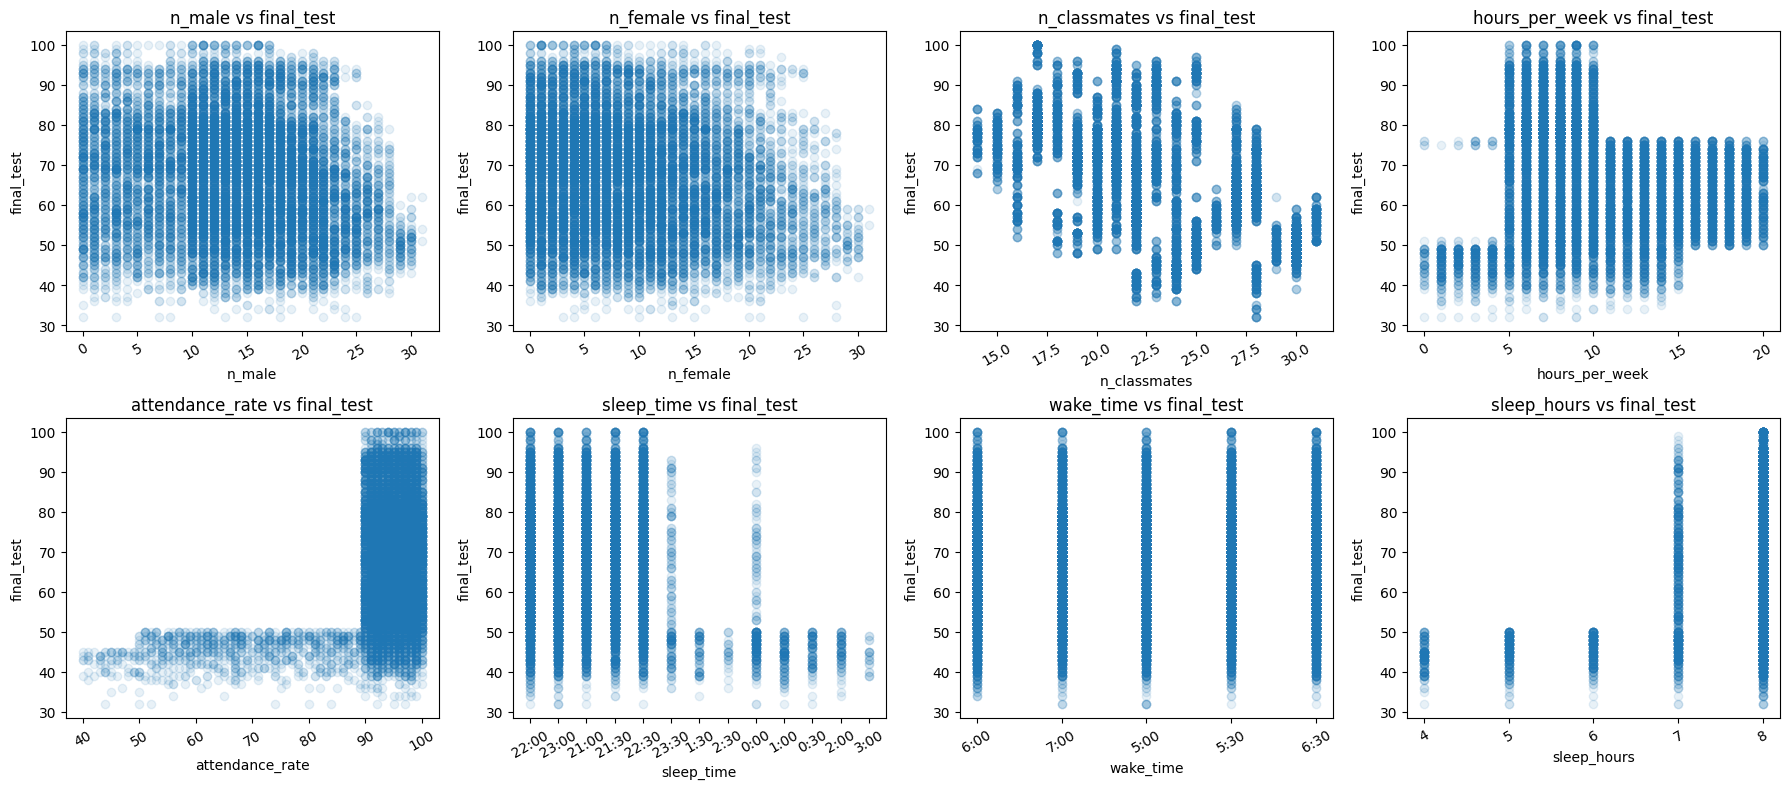

In [59]:
num_col = ['n_male', 'n_female', 'n_classmates','hours_per_week', 
           'attendance_rate', 'sleep_time', 'wake_time', 'sleep_hours']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()     

for col, ax in zip(num_col, axes):
    ax.scatter(df_cleaned[col], df_cleaned['final_test'], alpha=0.1)
    ax.set_title(f'{col} vs final_test')
    ax.set_xlabel(col)
    ax.set_ylabel('final_test')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

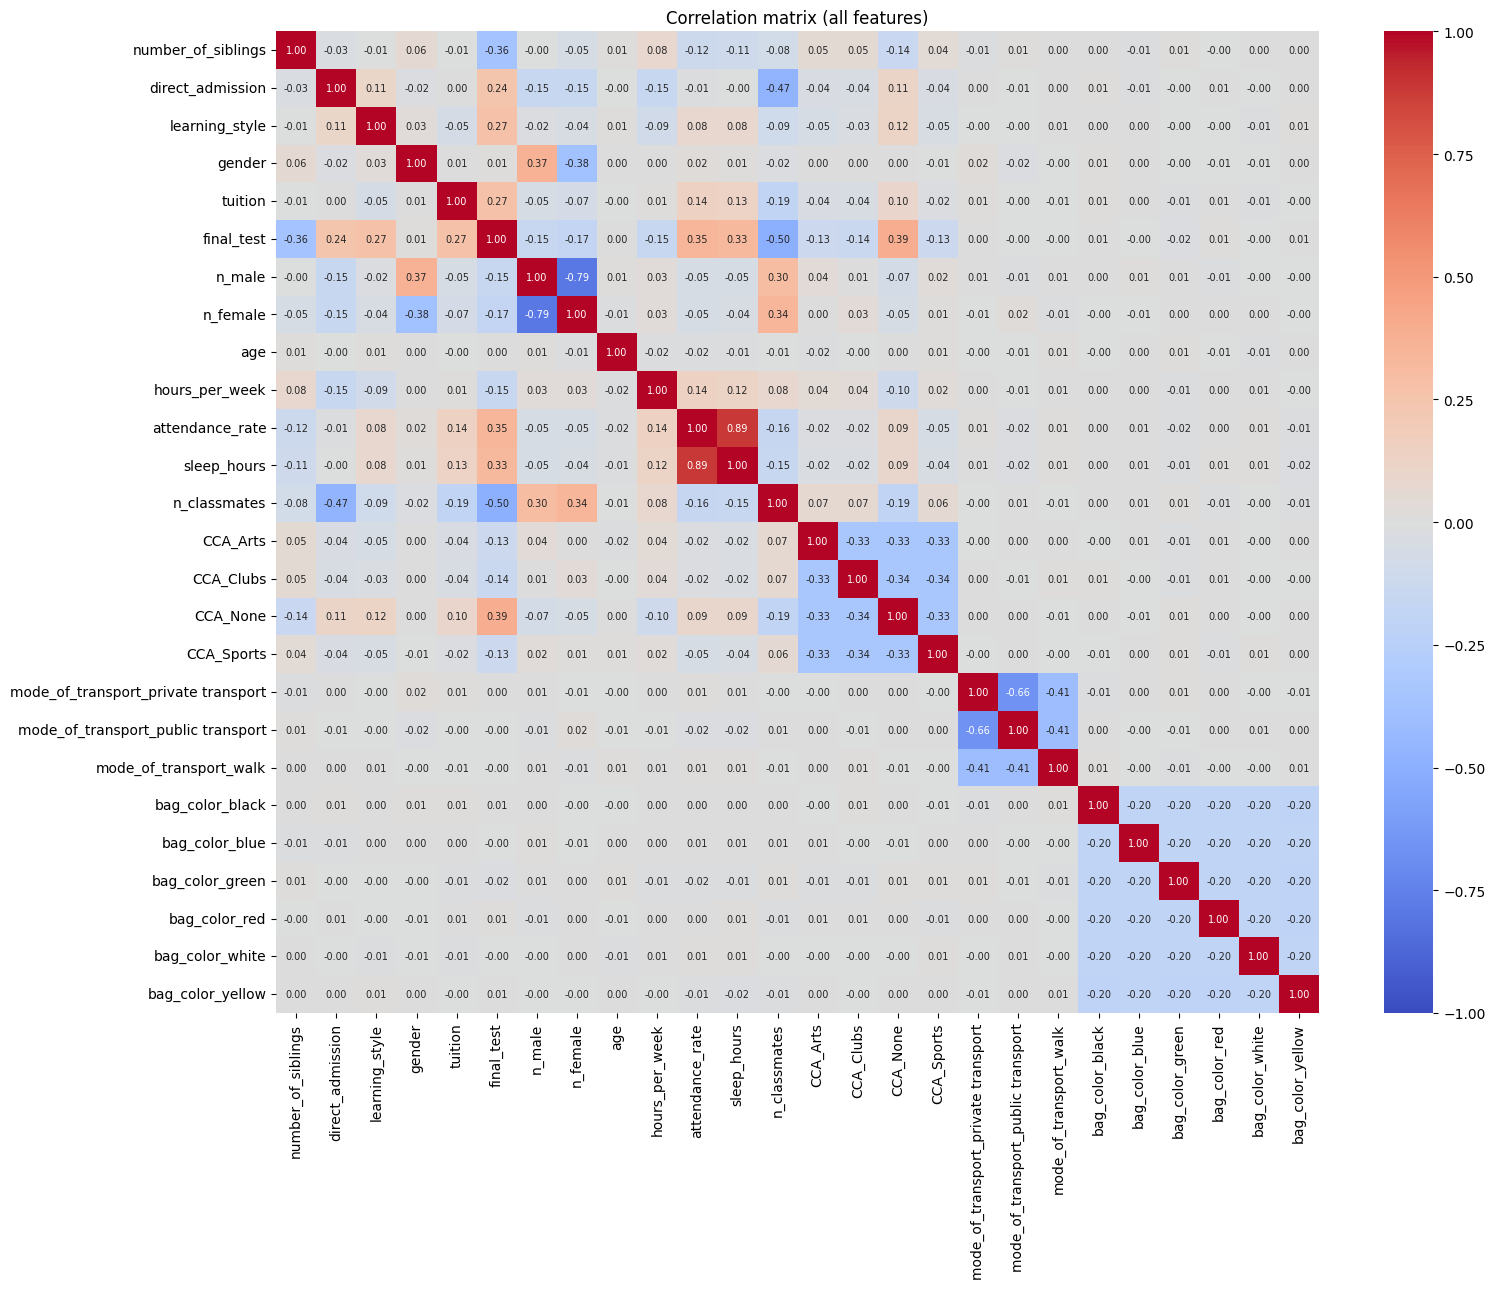

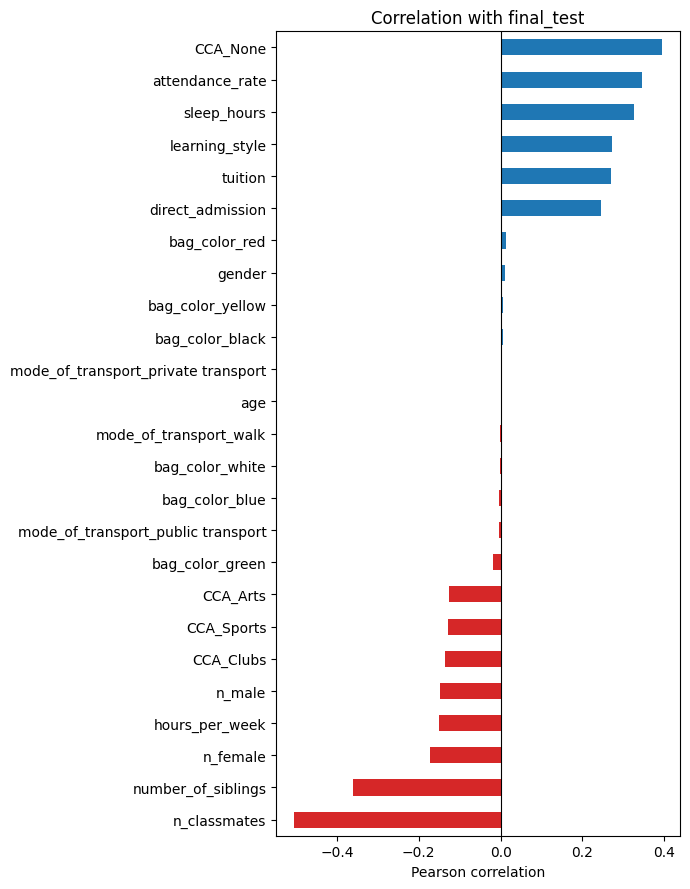

In [ ]:
# Build a numeric-only copy for correlation
heat_df = df_cleaned.drop(columns=['index', 'student_id', 'sleep_time', 'wake_time'])

# 1. Two-value categories, 0/1
binary_map = {'direct_admission': {'Yes': 1, 'No': 0},
              'tuition':          {'Yes': 1, 'No': 0},
              'gender':           {'Male': 1, 'Female': 0},
              'learning_style':   {'Visual': 1, 'Auditory': 0}}
for col, mapping in binary_map.items():
    heat_df[col] = heat_df[col].map(mapping)

# 2. Multi-value categories, 0/1 column per category
heat_df = pd.get_dummies(heat_df, columns=['CCA', 'mode_of_transport', 'bag_color'],dtype=int)

corr = heat_df.corr()

# Plot 1: full heatmap 
plt.figure(figsize=(16, 13))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Correlation matrix (all features)')
plt.tight_layout()
plt.show()

# Plot 2: correlation with final_test only, ranked
target_corr = corr['final_test'].drop('final_test').sort_values()

plt.figure(figsize=(7, 9))
target_corr.plot(kind='barh',color=['tab:red' if v < 0 else 'tab:blue' for v in target_corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation with final_test')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()